In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# Se cambia el nombre de la app de Camila Rojas a Bastian Bravo
spark = SparkSession.builder.appName("Semana12_Regresion_Bastian_Bravo").getOrCreate()

# Cargar datos etiquetados generados en Semana 10 (mantiene la ruta de tu contenedor)
df_clusters = spark.read.parquet("/home/jovyan/work/semanas/Semana 10/modelos/datos_etiquetados_kmeans")

print(f"Datos cargados: {df_clusters.count()}")
print("Columnas disponibles:")
print(df_clusters.columns)
df_clusters.show(5)


Datos cargados: 4415
Columnas disponibles:
['precio_noche', 'estrellas', 'puntuacion', 'noches', 'features', 'scaledFeatures', 'prediction']
+------------+---------+----------+------+--------------------+--------------------+----------+
|precio_noche|estrellas|puntuacion|noches|            features|      scaledFeatures|prediction|
+------------+---------+----------+------+--------------------+--------------------+----------+
|    386540.0|      4.0|       8.4|   1.0|[386540.0,4.0,8.4...|[2.10697214446551...|         1|
|     64896.0|      0.0|       8.7|   1.0|[64896.0,0.0,8.7,...|[0.35373845989350...|         0|
|    171927.0|      0.0|       9.8|   1.0|[171927.0,0.0,9.8...|[0.93714854835598...|         0|
|     51041.0|      0.0|       9.6|   1.0|[51041.0,0.0,9.6,...|[0.27821691215828...|         0|
|    150000.0|      0.0|      10.0|   1.0|[150000.0,0.0,10....|[0.81762772719466...|         0|
+------------+---------+----------+------+--------------------+--------------------+-------

In [2]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Usar estrellas, puntuacion, noches y cluster como predictores
# Variable objetivo: precio_noche
df_num = df_clusters.select(
    col("precio_noche").cast("double").alias("label_precio"),
    col("estrellas").cast("double").alias("estrellas"),
    col("puntuacion").cast("double").alias("puntuacion"),
    col("noches").cast("double").alias("noches"),
    col("prediction").cast("double").alias("cluster")
).na.fill({
    "label_precio": 0.0,
    "estrellas": 0.0,
    "puntuacion": 0.0,
    "noches": 1.0,
    "cluster": 0.0
})

variables_regresion = ["estrellas", "puntuacion", "noches", "cluster"]

# Vectorizar
assembler = VectorAssembler(
    inputCols=variables_regresion,
    outputCol="features_reg",
    handleInvalid="skip"
)
df_vector = assembler.transform(df_num)

# Escalar
scaler = StandardScaler(inputCol="features_reg", outputCol="scaledFeatures_reg", withStd=True, withMean=False)
scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

# Dividir en entrenamiento y prueba
train_reg, test_reg = df_scaled.randomSplit([0.7, 0.3], seed=42)

print(f"Entrenamiento: {train_reg.count()}")
print(f"Prueba: {test_reg.count()}")


Entrenamiento: 3157
Prueba: 1258


In [3]:
# Entrenar modelo
lr_reg = LinearRegression(featuresCol="scaledFeatures_reg", labelCol="label_precio", maxIter=100)
lr_model = lr_reg.fit(train_reg)
predictions = lr_model.transform(test_reg)

# Evaluar
evaluator_r2 = RegressionEvaluator(labelCol="label_precio", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol="label_precio", metricName="rmse")

r2 = evaluator_r2.evaluate(predictions)
rmse = evaluator_rmse.evaluate(predictions)

print("=" * 50)
print("REGRESION LINEAL - PREDICCION DE PRECIO")
print("=" * 50)
print(f"R2:  {r2 * 100:.2f}%")
print(f"RMSE: ${rmse:,.0f} CLP")
print("=" * 50)


REGRESION LINEAL - PREDICCION DE PRECIO
R2:  3.32%
RMSE: $130,641 CLP


In [4]:
print(f"Intercepto (precio base): ${lr_model.intercept:,.0f} CLP")
print("Coeficientes por variable:")
for i, var in enumerate(variables_regresion):
    print(f"  {var}: ${lr_model.coefficients[i]:,.0f} CLP")


Intercepto (precio base): $275,915 CLP
Coeficientes por variable:
  estrellas: $-50,740 CLP
  puntuacion: $138 CLP
  noches: $-37,104 CLP
  cluster: $87,519 CLP


+------------+------------------+
|label_precio|        prediction|
+------------+------------------+
|         0.0|102318.07290251416|
|         0.0|102318.07290251416|
|         0.0|102318.07290251416|
|         0.0|102318.07290251416|
|         0.0|102318.07290251416|
|         0.0|102318.07290251416|
|         0.0|102318.07290251416|
|         0.0|102318.07290251416|
|         0.0|102318.07290251416|
|         0.0|102318.07290251416|
+------------+------------------+
only showing top 10 rows



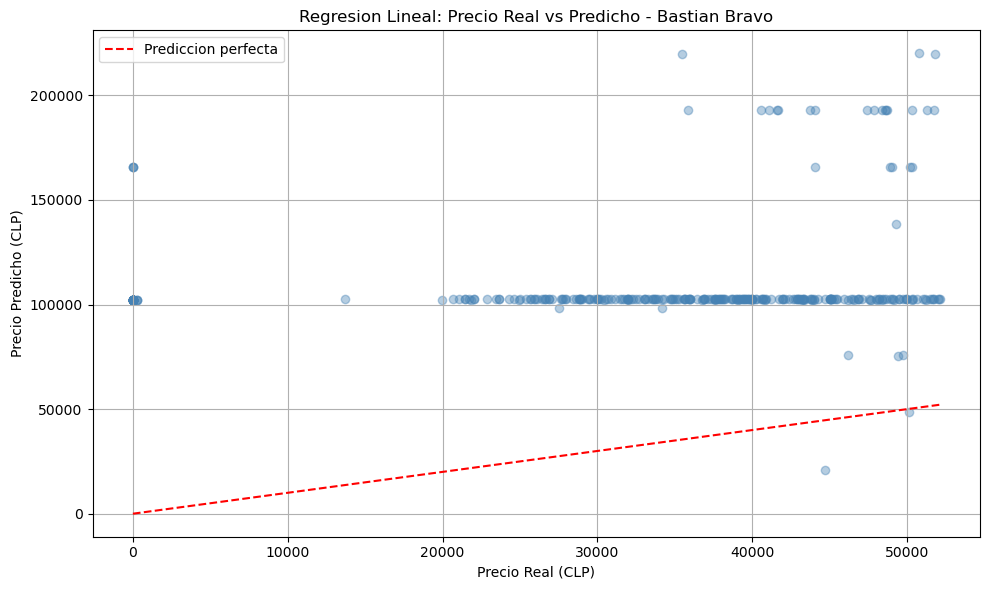

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Mostrar tabla comparativa
predictions.select("label_precio", "prediction").show(10)

# Grafico real vs predicho
pdf_pred = predictions.select("label_precio", "prediction").limit(300).toPandas()

plt.figure(figsize=(10, 6))
plt.scatter(pdf_pred["label_precio"], pdf_pred["prediction"], alpha=0.4, color="steelblue")
plt.plot(
    [pdf_pred["label_precio"].min(), pdf_pred["label_precio"].max()],
    [pdf_pred["label_precio"].min(), pdf_pred["label_precio"].max()],
    "r--", label="Prediccion perfecta"
)
plt.xlabel("Precio Real (CLP)")
plt.ylabel("Precio Predicho (CLP)")

# Se cambia el título para que muestre tu nombre
plt.title("Regresion Lineal: Precio Real vs Predicho - Bastian Bravo")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
